## 04 - Model training

### 🎯 Model objective

As stated before, the objective of the project is to have a program that takes as input two reactives in SMILES and gives back a list of the best conditions with their predicted yield for the **Suzuki coupling** reaction. The conditions include the **base, ligand, and solvent** used. For this, the program needs a model that takes as input a **vector of descriptors** containing significant information about the two reactives and gives back the wanted results.


### 🏛️ Notebook Structure

To accomplish this objective, multiple different models will be tested. Different models will be trained and a few preliminary tests will be made.

First, preliminary tasks will be performed. The necessary libraries and functions will be imported, and functions to evaluate and compare the models will be defined.

Then for each model, the section will contain :

- A brief explanation of the model operation.
- The creation of the required models, their training, and eventual adjustments.
- The testing of the model, where its accuracy will be tested.

The final model will be chosen based on **a comparative accuracy assessment** in the next notebook.

## Preliminary tasks

Before training and testing the models in their different strategies, a few preliminary tasks have to be done.

### 📚 Library and functions imports

A few libraries and functions will be necessary throughout the notebook. 

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import pytorch_lightning as pl
import joblib

# Import necessary functions
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from pytorch_lightning.callbacks import EarlyStopping, Callback
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

### 💯 Testing function

To evaluate the models, a function that calculates multiple evaluation metrics is defined.

In [2]:
# Testing function
def test_model(model_name, y_true, y_pred):
    """
    Test the model predictions and return multiple evaluation metrics.
    Parameters:
    model_name: The name of the model being evaluated.
    y_true: The true labels for the test dataset.
    y_pred: The predicted labels for the test dataset.
    Returns:
    A dictionary containing the evaluation metrics: RMSE, MAE, R2 Score, and Explained Variance Score.
    """
    if y_true is None:
        raise ValueError("y_true must be provided")
    if y_pred is None:
        raise ValueError("y_pred must be provided")

    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    explained_variance = explained_variance_score(y_true, y_pred)

    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2 Score": r2,
        "Explained Variance Score": explained_variance
    }

Here, it was decided to use the Root Mean Squared Error, the Mean Absolute Error, the R-Squared Score and the Explained Variance Score. This set of metrics involves a good equilibrium between interpretability and robustness. 

These functions are also stored in model_utils.py to be reusable in other notebooks.

### 📩 Import and store the training and testing data

The training and testing data must be imported in the notebook for the next operations.

In [3]:
# Import the data
x_train = np.load("../data/final/Split new/X_train.npy")
y_train = np.load("../data/final/Split new/y_train.npy")
x_test  = np.load("../data/final/Split new/X_test.npy")
y_test  = np.load("../data/final/Split new/y_test.npy")
x_tot = np.load("../data/final/Complete/X_features.npy")
y_tot = np.load("../data/final/Complete/y_target.npy")

# Print the shapes of the datasets
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"x_tot shape: {x_tot.shape}")
print(f"y_tot shape: {y_tot.shape}")

# Convert percentage yield values from 0-100 into a 0-1 range
y_train = y_train / 100.0
y_test = y_test / 100.0

# The standardization and scaling will probably be done in a different notebook, but it is defined here for now.

x_train shape: (4608, 473)
y_train shape: (4608,)
x_test shape: (1152, 473)
y_test shape: (1152,)
x_tot shape: (5760, 473)
y_tot shape: (5760,)


## The Model Strategy

The strategy is straight-forward. A model takes as input a vector of descriptors containing information about the two reactives and the combination of reaction conditions. It would then return the expected yield for this particular combination. The model would then be used to predict the yield of every combination of ligand, base, and solvent with the input reactives. The results could then be sorted and the conditions selected. 

Here is a summary of the number of ligands, bases, and solvents:

| Element | Number |
|---|---|
| **Ligands** | 11 ligands + "no ligand" |
| **Bases** | 7 bases + "no base" | 
| **Solvents** | 6 solvents |

This amounts to 576 combinations when accounting for the possibility of no ligand or base. This method may seem slow and computationnaly expensive, but testing such a low amount of combinations is reasonable, especially if it allows the use of simpler strategies.


### Models to test

The following models will be tested to apply this strategy:

- Random Forest Regressor
- XGboost Regressor
- Deep Learning Model

All the models return a single value when given a vector as input.

### Model definition, training, and testing on treated features

**Random Forest**

This model is composed of **multiple trees** that are each trained on a different subset of the training dataset. When given an input, each tree processes the input vector and returns a single value. The output predicted value is **the average of all the proposed results**.

**XGBoost**

**Extreme gradient boosting** model is constructed by buildent decision trees one after the other. Each new tree attempts to correct the error of the previous one. It uses **gradient based optimization** to improve its performance. The final tree is used to predict the value of interest.

In [7]:
# Use iterative halving search for hyperparameter tuning
# Parameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 200, 400],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None],
}

# Parameter grid for XGBoost
xgb_param_grid = {
    'n_estimators': [50, 100, 200, 400],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
}

# Random Forest Regressor
halving_search_ranf = HalvingGridSearchCV(
    estimator=RandomForestRegressor(random_state=0),
    param_grid=rf_param_grid,
    cv=10,
    factor=2,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0, # Set higher for more detailed output during the search
)
halving_search_ranf.fit(x_train, y_train)
print("Best parameters for Random Forest:", halving_search_ranf.best_params_)

# XGBoost Regressor
halving_search_xgb = HalvingGridSearchCV(
    estimator=XGBRegressor(random_state=0, objective='reg:squarederror'),
    param_grid=xgb_param_grid,
    cv=5,
    factor=2,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0, # Set higher for more detailed output during the search
)
halving_search_xgb.fit(x_train, y_train)
print("Best parameters for XGBoost:", halving_search_xgb.best_params_)

Best parameters for Random Forest: {'max_depth': 30, 'max_features': None, 'min_samples_split': 2, 'n_estimators': 400}
Best parameters for XGBoost: {'colsample_bytree': 0.6, 'learning_rate': 0.03, 'max_depth': 10, 'n_estimators': 200, 'subsample': 0.6}


In [8]:
# Test the models 
y_pred_ranf = halving_search_ranf.best_estimator_.predict(x_test)
y_pred_xgb = halving_search_xgb.best_estimator_.predict(x_test)

print(test_model("RandomForest", y_test, y_pred_ranf))
print(test_model("XGBoost", y_test, y_pred_xgb))

# Predict on the first 5 test vectors and display results
num_samples = 5
print("\nPredictions for first 5 test vectors:")
for i in range(num_samples):
    print(f"Tested vector {i+1}, Random Forest predicted yield: {y_pred_ranf[i]:.4f}, actual yield: {y_test[i]:.4f}")
    print(f"Tested vector {i+1}, XGBoost predicted yield: {y_pred_xgb[i]:.4f}, actual yield: {y_test[i]:.4f}")
    print("")

{'Model': 'RandomForest', 'RMSE': 0.106031926807209, 'MAE': 0.0746237202610995, 'R2 Score': 0.8607591804758017, 'Explained Variance Score': 0.8607923613581951}
{'Model': 'XGBoost', 'RMSE': 0.0998001465858722, 'MAE': 0.06894593358061835, 'R2 Score': 0.8766453225090355, 'Explained Variance Score': 0.8766991843262137}

Predictions for first 5 test vectors:
Tested vector 1, Random Forest predicted yield: 0.2881, actual yield: 0.1710
Tested vector 1, XGBoost predicted yield: 0.2768, actual yield: 0.1710

Tested vector 2, Random Forest predicted yield: 0.3279, actual yield: 0.3646
Tested vector 2, XGBoost predicted yield: 0.3038, actual yield: 0.3646

Tested vector 3, Random Forest predicted yield: 0.8185, actual yield: 0.7698
Tested vector 3, XGBoost predicted yield: 0.7898, actual yield: 0.7698

Tested vector 4, Random Forest predicted yield: 0.2546, actual yield: 0.0000
Tested vector 4, XGBoost predicted yield: 0.3378, actual yield: 0.0000

Tested vector 5, Random Forest predicted yield: 

(future comments about the models performance, complete once the defenitive version is created)

### Model definition, training and testing on randomly splitted features

For completeness, the models can be trained on different total feature splits to observe the evolution of model performance depending on the split fractions. First, the total data must be split, then the regressors will be trained and tested on each splitted set. The 4 metrics are plotted against the train split fraction for comparison. 

In [9]:
# Split the data into training and testing sets, validation is set only in the neural network training section
# 50% training, 50% testing
X_train_50, X_test_50, y_train_50, y_test_50 = train_test_split(x_tot, y_tot, test_size=0.5, random_state=42)

# 60% training, 40% testing
X_train_60, X_test_60, y_train_60, y_test_60 = train_test_split(x_tot, y_tot, test_size=0.4, random_state=42)

# 70% training, 30% testing
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(x_tot, y_tot, test_size=0.3, random_state=42)

# 80% training, 20% testing
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(x_tot, y_tot, test_size=0.2, random_state=42)

# 90% training, 10% testing
X_train_90, X_test_90, y_train_90, y_test_90 = train_test_split(x_tot, y_tot, test_size=0.1, random_state=42)

In [10]:
# data storage for the training loops, this will be used to store the different splits of the data for the training loops
splits = {
    "50% Train / 50% Test": (X_train_50, y_train_50, X_test_50, y_test_50),
    "60% Train / 40% Test": (X_train_60, y_train_60, X_test_60, y_test_60),
    "70% Train / 30% Test": (X_train_70, y_train_70, X_test_70, y_test_70),
    "80% Train / 20% Test": (X_train_80, y_train_80, X_test_80, y_test_80),
    "90% Train / 10% Test": (X_train_90, y_train_90, X_test_90, y_test_90),
}

# Parameter grids are redefined here for the training loops, these are smaller than the previous ones to reduce training time
# Parameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [5, 10],
    'max_features': ['sqrt', 'log2', None],
}

# Parameter grid for XGBoost
xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.03, 0.05],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

# Models redifined here for the training loops, may feature different hyperparameters than the previous models, different names to avoid overwriting the previous models
# Random Forest Regressor
halving_search_ranf_t = HalvingGridSearchCV(
    estimator=RandomForestRegressor(random_state=0),
    param_grid=rf_param_grid,
    cv=5,
    factor=2,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0,
)

# XGBoost Regressor
halving_search_xgb_t = HalvingGridSearchCV(
    estimator=XGBRegressor(random_state=0, objective='reg:squarederror'),
    param_grid=xgb_param_grid,
    cv=5,
    factor=2,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0,
)

In [11]:
# Store metrics for plotting
metrics_data = {
    "Random Forest": {"Train Fraction": [], "RMSE": [], "MAE": [], "R2 Score": [], "Explained Variance": []},
    "XGBoost": {"Train Fraction": [], "RMSE": [], "MAE": [], "R2 Score": [], "Explained Variance": []},
}

# Training loops for each split
for split_name, (X_train_t, y_train_t, X_test_t, y_test_t) in splits.items(): # added 't' to the variables because they may cause overwriting of y_train
    # Extract train fraction (e.g., 50% from "50% Train / 50% Test")
    train_fraction = int(split_name.split("%")[0])

    print(f"\nTraining on split: {split_name}")

    # Train Random Forest
    halving_search_ranf_t.fit(X_train_t, y_train_t)
    y_pred_ranf = halving_search_ranf_t.best_estimator_.predict(X_test_t)
    metrics_ranf = test_model(f"RandomForest ({split_name})", y_test_t, y_pred_ranf)
    print(metrics_ranf)

    # Store Random Forest metrics
    metrics_data["Random Forest"]["Train Fraction"].append(train_fraction)
    metrics_data["Random Forest"]["RMSE"].append(metrics_ranf["RMSE"])
    metrics_data["Random Forest"]["MAE"].append(metrics_ranf["MAE"])
    metrics_data["Random Forest"]["R2 Score"].append(metrics_ranf["R2 Score"])
    metrics_data["Random Forest"]["Explained Variance"].append(metrics_ranf["Explained Variance Score"])

    # Train XGBoost
    halving_search_xgb_t.fit(X_train_t, y_train_t)
    y_pred_xgb = halving_search_xgb_t.best_estimator_.predict(X_test_t)
    metrics_xgb = test_model(f"XGBoost ({split_name})", y_test_t, y_pred_xgb)
    print(metrics_xgb)

    # Store XGBoost metrics
    metrics_data["XGBoost"]["Train Fraction"].append(train_fraction)
    metrics_data["XGBoost"]["RMSE"].append(metrics_xgb["RMSE"])
    metrics_data["XGBoost"]["MAE"].append(metrics_xgb["MAE"])
    metrics_data["XGBoost"]["R2 Score"].append(metrics_xgb["R2 Score"])
    metrics_data["XGBoost"]["Explained Variance"].append(metrics_xgb["Explained Variance Score"])


Training on split: 50% Train / 50% Test
{'Model': 'RandomForest (50% Train / 50% Test)', 'RMSE': 12.021143743870747, 'MAE': 8.456480234331858, 'R2 Score': 0.8198105478399702, 'Explained Variance Score': 0.8198744756268248}
{'Model': 'XGBoost (50% Train / 50% Test)', 'RMSE': 11.632479224401258, 'MAE': 8.22600654547249, 'R2 Score': 0.8312738661176882, 'Explained Variance Score': 0.8312879322028545}

Training on split: 60% Train / 40% Test
{'Model': 'RandomForest (60% Train / 40% Test)', 'RMSE': 11.511021996518098, 'MAE': 8.156486996567208, 'R2 Score': 0.833016103356141, 'Explained Variance Score': 0.8330442691994967}
{'Model': 'XGBoost (60% Train / 40% Test)', 'RMSE': 10.89142273253051, 'MAE': 7.756454466588727, 'R2 Score': 0.8505086536546946, 'Explained Variance Score': 0.8505425337557192}

Training on split: 70% Train / 30% Test
{'Model': 'RandomForest (70% Train / 30% Test)', 'RMSE': 11.281413469398396, 'MAE': 7.9422005479086675, 'R2 Score': 0.836551111668253, 'Explained Variance Sco

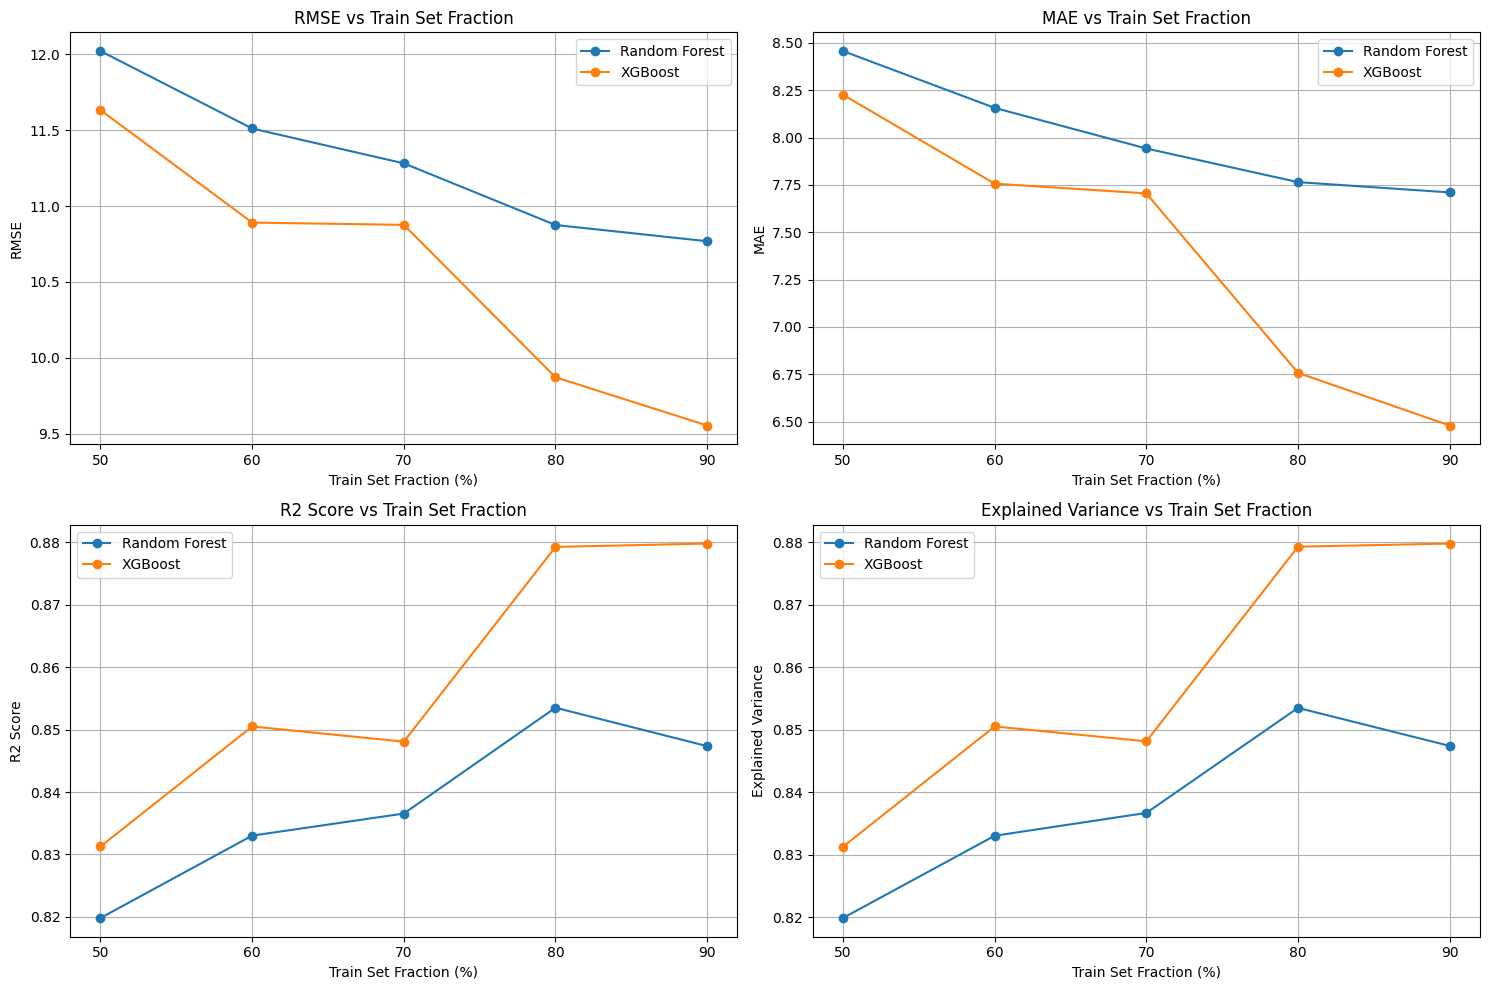

In [12]:
# Plot the metrics for both models across different training set fractions for better visualization of the results
plt.figure(figsize=(15, 10))

# Metrics to plot
metrics_to_plot = ["RMSE", "MAE", "R2 Score", "Explained Variance"]

for i, metric in enumerate(metrics_to_plot, 1):
    plt.subplot(2, 2, i)
    for model_name in metrics_data:
        x = metrics_data[model_name]["Train Fraction"]
        y = metrics_data[model_name][metric]
        plt.plot(x, y, marker='o', label=model_name)
        plt.xlabel("Train Set Fraction (%)")
        plt.ylabel(metric)
        plt.title(f"{metric} vs Train Set Fraction")
        plt.xticks([50, 60, 70, 80, 90])
        plt.grid(True)
        plt.legend()

plt.tight_layout()
plt.show()

(future comments about the models performance, complete once the defenitive version is created)

**Deep Learning Model**

This model makes use of a neural networks consisting of **multiples interconnected node layers**. Each one applies a function to its inputs with different **weights**, and sends the output to the next layer. The last node will take the outputs of all the previous layer's nodes and calculate a single value which is the predicted reaction yield. The number of layers, layer size, dropout rate, learning rate, and other important hyperparameters will have to be adjusted to have a better performing model.

In [13]:
class NeuralNetwork(pl.LightningModule):
    def __init__(self, input_sz, hidden_sz=128, lr=1e-4):
        super().__init__()

        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_sz, hidden_sz), # There is currently 3 hidden layers, but this can be easily changed by adding more blocks of Linear, ReLU, BatchNorm, and Dropout
            torch.nn.ReLU(),
            torch.nn.BatchNorm1d(hidden_sz),
            torch.nn.Dropout(0.4),

            torch.nn.Linear(hidden_sz, hidden_sz),
            torch.nn.ReLU(),
            torch.nn.BatchNorm1d(hidden_sz),
            torch.nn.Dropout(0.4),

            torch.nn.Linear(hidden_sz, hidden_sz),
            torch.nn.ReLU(),
            torch.nn.BatchNorm1d(hidden_sz),
            torch.nn.Dropout(0.4),

            torch.nn.Linear(hidden_sz, 1)
        )

        self.lr = lr

    def forward(self, x):
        return self.net(x)

    def _shared_step(self, batch):
        x, y = batch
        preds = self(x)
        loss = F.mse_loss(preds, y)
        return loss

    def training_step(self, batch, batch_idx):
        loss = self._shared_step(batch)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        loss = self._shared_step(batch)
        self.log("val_loss", loss)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

In [14]:
# Define a custom dataset class for PyTorch
class ESOLDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Define a PyTorch Lightning DataModule for handling data loading
class NeuralNetworkDataModule(pl.LightningDataModule):
    def __init__(self, train_dataset, val_dataset, test_dataset, batch_size=128):
        super().__init__()
        self.train_dataset = train_dataset
        self.val_dataset = val_dataset
        self.test_dataset = test_dataset
        self.batch_size = batch_size

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\corre\Documents\GitHub_gen\GitHub\.venv\lib\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default

  | Name | Type       | Params | Mode  | FLOPs
----------------------------------------------------
0 | net  | Sequential | 94.6 K | train | 0    
---------------------

(4608, 473) (4608,)
                                                                           

c:\Users\corre\Documents\GitHub_gen\GitHub\.venv\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
c:\Users\corre\Documents\GitHub_gen\GitHub\.venv\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
c:\Users\corre\Documents\GitHub_gen\GitHub\.venv\lib\site-packages\pytorch_lightning\loops\fit_loop.py:317: The number of training batches (29) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 118: 100%|██████████| 29/29 [00:00<00:00, 89.28it/s, v_num=6] 


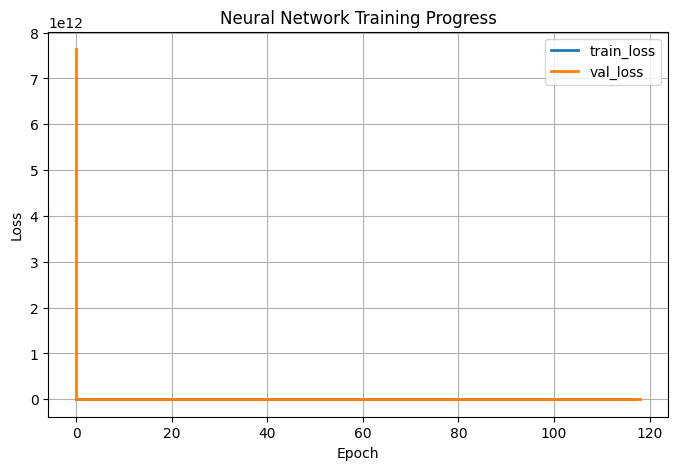

In [15]:
# Initialize the model, data module, and trainer
input_size = x_train.shape[1]
hidden_size = 128
model = NeuralNetwork(input_size, hidden_size)
print(x_train.shape, y_train.shape)

# Split the training data into training and validation sets
x_train_split, x_val, y_train_split, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)
train_dataset = ESOLDataset(x_train_split, y_train_split)

# Create datasets for validation and testing
val_dataset = ESOLDataset(x_val, y_val)
test_dataset = ESOLDataset(x_test, y_test)
data_module = NeuralNetworkDataModule(train_dataset, val_dataset, test_dataset)

# Capture training and validation loss history during training
class TrainingHistoryCallback(Callback):
    def __init__(self):
        super().__init__()
        self.train_losses = []
        self.val_losses = []
        self.epochs = []

    def on_train_epoch_end(self, trainer, pl_module):
        train_loss = trainer.callback_metrics.get("train_loss")
        if train_loss is not None:
            self.train_losses.append(float(train_loss))
        else:
            self.train_losses.append(None)

    def on_validation_epoch_end(self, trainer, pl_module):
        val_loss = trainer.callback_metrics.get("val_loss")
        self.epochs.append(trainer.current_epoch)
        if val_loss is not None:
            self.val_losses.append(float(val_loss))
        else:
            self.val_losses.append(None)

history_callback = TrainingHistoryCallback()
# Initialize the PyTorch Lightning trainer
early_stop = EarlyStopping(monitor="val_loss", patience=10)
trainer = pl.Trainer(max_epochs=500, callbacks=[early_stop, history_callback], enable_progress_bar=True)

# Train the model
trainer.fit(model, data_module)

# Plot training progress over epochs
plt.figure(figsize=(8, 5))
plt.plot(history_callback.epochs[:-1], history_callback.train_losses, label="train_loss", linewidth=2)
plt.plot(history_callback.epochs, history_callback.val_losses, label="val_loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Neural Network Training Progress")
plt.legend()
plt.grid(True)
plt.show()


In [16]:
# Test the model
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    y_pred_nn = model(torch.tensor(x_test, dtype=torch.float32)).squeeze().numpy()

print(test_model("NeuralNetwork", y_test, y_pred_nn))

# Predict on the first 5 test vectors and display results
x_sample = torch.tensor(x_test[:5], dtype=torch.float32)
with torch.no_grad():
    y_pred_sample_nn = model(x_sample).squeeze().numpy()

num_samples = 5
print("\nPredictions for first 5 test vectors (Neural Network):")
for i in range(num_samples):
    print(f"Tested vector {i+1}, Neural Network predicted yield: {y_pred_sample_nn[i]:.4f}, actual yield: {y_test[i]:.4f}")
    print("")

{'Model': 'NeuralNetwork', 'RMSE': 0.26893190319832183, 'MAE': 0.2266438765191675, 'R2 Score': 0.1042683613344334, 'Explained Variance Score': 0.11241418658708102}

Predictions for first 5 test vectors (Neural Network):
Tested vector 1, Neural Network predicted yield: 0.4289, actual yield: 0.1710

Tested vector 2, Neural Network predicted yield: 0.4277, actual yield: 0.3646

Tested vector 3, Neural Network predicted yield: 0.4289, actual yield: 0.7698

Tested vector 4, Neural Network predicted yield: 0.4289, actual yield: 0.0000

Tested vector 5, Neural Network predicted yield: 0.4287, actual yield: 0.4383



(future comments about the model performance, complete once the defenitive version is created)

### 💾 Model Saving

The models and data scaler must now be saved to make them reusable in the next notebook, dedicated to their more thorough testing.

In [17]:
# Save the trained regression models
joblib.dump(halving_search_ranf.best_estimator_, "../models/RandomForest.pth")
joblib.dump(halving_search_xgb.best_estimator_, "../models/XGBoost.pth")

# Save the trained neural network model 
trainer.save_checkpoint("../models/lightning_nn.ckpt")

`weights_only` was not set, defaulting to `False`.
